# 🪄 Datathon — Fase 05: Case Passos Mágicos

**Pós Tech FIAP | Data Analytics**


**Aluno:** Gustavo Henrique Lisboa do Nascimento

---

## 📌 Contexto

A Associação Passos Mágicos atua há mais de 35 anos na transformação da vida
de crianças e jovens em vulnerabilidade social, por meio de educação, apoio
psicológico/psicopedagógico e ampliação de horizontes. 
A associação mede o desenvolvimento educacional de seus alunos com a pesquisa
**PEDE** (Pesquisa Extensiva do Desenvolvimento Educacional).

**O desafio:** usar os dados PEDE de 2022, 2023 e 2024 para responder 11
perguntas de negócio sobre a efetividade do programa, em formato de
storytelling gerencial, e construir um **modelo preditivo de risco de
defasagem escolar**, disponibilizado depois como aplicação Streamlit.

---

## Bibliotecas e configuração

### Objetivo do bloco
Preparar o ambiente: importar as bibliotecas de manipulação de dados,
visualização e machine learning, e configurar o carregamento do arquivo de
dados.

In [1]:
import os
import re
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import joblib

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (8, 4.5)
RANDOM_STATE = 42

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (8, 4.5)
RANDOM_STATE = 42

PEDE_RAW_URL = f"https://docs.google.com/spreadsheets/d/1UUskvMm-T9mS3oN7LkxZy78IfAIXYhQc/export?format=xlsx"

print("✅ Bibliotecas carregadas | fonte de dados:", PEDE_RAW_URL)

✅ Bibliotecas carregadas | fonte de dados: https://docs.google.com/spreadsheets/d/1UUskvMm-T9mS3oN7LkxZy78IfAIXYhQc/export?format=xlsx


---

## Importando e carregando o arquivo

### Objetivo do bloco
Ler as três abas da planilha bruta  e conferir o formato de cada uma.

In [2]:
xls = pd.ExcelFile(PEDE_RAW_URL)
df22 = pd.read_excel(xls, "PEDE2022")
df23 = pd.read_excel(xls, "PEDE2023")
df24 = pd.read_excel(xls, "PEDE2024")

print("PEDE2022:", df22.shape)
print("PEDE2023:", df23.shape)
print("PEDE2024:", df24.shape)
df22.head(3)

PEDE2022: (860, 42)
PEDE2023: (1014, 48)
PEDE2024: (1156, 50)


,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,INDE 22,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,Rec Psicologia,IDA,Matem,Portug,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,753,18,10,4,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.3,4.1,5.6,Requer avaliação,4.0,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,7.055,469,8,3,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.8,5.2,6.3,Sem limitações,6.8,6.3,4.5,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ágata,6.591,629,13,6,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,0.0,7.9,5.6,Sem limitações,5.6,5.8,4.0,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...


---

## Dicionário de Dados

Todos os indicadores variam de **0 a 10** e compõem o **INDE** (Índice do
Desenvolvimento Educacional), a nota-síntese de cada aluno.

| Sigla | Nome em português | Descrição |
|---|---|---|
| `RA` | Registro do Aluno | Identificador único do aluno |
| `IAN` | Adequação de Nível | Fase atual está de acordo com a idade? |
| `IDA` | Desempenho Acadêmico | Média de Matemática, Português e Inglês |
| `IEG` | Engajamento | Participação em tarefas/atividades/voluntariado |
| `IAA` | Autoavaliação | Percepção do próprio aluno sobre si mesmo |
| `IPS` | Psicossocial | Avaliação de psicólogos |
| `IPP` | Psicopedagógico | Avaliação pedagógica (só existe a partir de 2023) |
| `IPV` | Ponto de Virada | Progresso longitudinal (acadêmico/engaj./emocional) |
| `INDE` | Índice geral | Ponderação de IAN, IDA, IEG, IAA, IPS, IPP e IPV (peso duplo p/ IDA, IEG, IPV) |
| `Defasagem` | Fase efetiva − Fase ideal | Quanto o aluno está atrasado/adiantado |
| `Pedra` | Classificação pelo INDE | Quartzo < Ágata < Ametista < Topázio (cortes fixos de INDE) |

---

## Padronização e limpeza

### Objetivo do bloco
Unificar as três abas em um único schema de colunas, tratando os quatro
problemas listados acima.

In [3]:
def fase_to_num(valor):
    """Padroniza a Fase para um inteiro 0-8 (0 = Alfa)."""
    if pd.isna(valor):
        return np.nan
    s = str(valor).upper().strip()
    if "ALFA" in s:
        return 0
    m = re.search(r"(\d+)", s)
    return int(m.group(1)) if m else np.nan


d22 = pd.DataFrame({
    "ra": df22["RA"], "ano": 2022,
    "fase": df22["Fase"].apply(fase_to_num),
    "fase_ideal": df22["Fase ideal"].apply(fase_to_num),
    "defasagem": df22["Defas"], "pedra": df22["Pedra 22"], "inde": df22["INDE 22"],
    "iaa": df22["IAA"], "ieg": df22["IEG"], "ips": df22["IPS"], "ipp": np.nan,
    "ida": df22["IDA"], "ipv": df22["IPV"], "ian": df22["IAN"],
    "nota_mat": df22["Matem"], "nota_por": df22["Portug"], "nota_ing": df22["Inglês"],
    "genero": df22["Gênero"], "idade": df22["Idade 22"],
    "ano_ingresso": df22["Ano ingresso"], "instituicao_ensino": df22["Instituição de ensino"],
    "indicado_bolsa": df22["Indicado"], "atingiu_pv": df22["Atingiu PV"],
    "num_avaliacoes": df22["Nº Av"],
})

d23 = pd.DataFrame({
    "ra": df23["RA"], "ano": 2023,
    "fase": df23["Fase"].apply(fase_to_num),
    "fase_ideal": df23["Fase Ideal"].apply(fase_to_num),
    "defasagem": df23["Defasagem"], "pedra": df23["Pedra 2023"], "inde": df23["INDE 2023"],
    "iaa": df23["IAA"], "ieg": df23["IEG"], "ips": df23["IPS"], "ipp": df23["IPP"],
    "ida": df23["IDA"], "ipv": df23["IPV"], "ian": df23["IAN"],
    "nota_mat": df23["Mat"], "nota_por": df23["Por"], "nota_ing": df23["Ing"],
    "genero": df23["Gênero"], "idade": df23["Idade"],
    "ano_ingresso": df23["Ano ingresso"], "instituicao_ensino": df23["Instituição de ensino"],
    "indicado_bolsa": df23["Indicado"], "atingiu_pv": df23["Atingiu PV"],
    "num_avaliacoes": df23["Nº Av"],
})

d24 = pd.DataFrame({
    "ra": df24["RA"], "ano": 2024,
    "fase": df24["Fase"].apply(fase_to_num),
    "fase_ideal": df24["Fase Ideal"].apply(fase_to_num),
    "defasagem": df24["Defasagem"], "pedra": df24["Pedra 2024"], "inde": df24["INDE 2024"],
    "iaa": df24["IAA"], "ieg": df24["IEG"], "ips": df24["IPS"], "ipp": df24["IPP"],
    "ida": df24["IDA"], "ipv": df24["IPV"], "ian": df24["IAN"],
    "nota_mat": df24["Mat"], "nota_por": df24["Por"], "nota_ing": df24["Ing"],
    "genero": df24["Gênero"], "idade": df24["Idade"],
    "ano_ingresso": df24["Ano ingresso"], "instituicao_ensino": df24["Instituição de ensino"],
    "indicado_bolsa": df24["Indicado"], "atingiu_pv": df24["Atingiu PV"],
    "num_avaliacoes": df24["Nº Av"],
})

df = pd.concat([d22, d23, d24], ignore_index=True)
print(f"Shape consolidado: {df.shape}")
df.head()

Shape consolidado: (3030, 24)


,ra,ano,fase,fase_ideal,defasagem,pedra,inde,iaa,ieg,ips,ipp,ida,ipv,ian,nota_mat,nota_por,nota_ing,genero,idade,ano_ingresso,instituicao_ensino,indicado_bolsa,atingiu_pv,num_avaliacoes
0,RA-1,2022,7,8,-1,Quartzo,5.783,8.3,4.1,5.6,NaN,4.0,7.278,5.0,2.7,3.5,6.0,Menina,19,2016,Escola Pública,Sim,Não,4.0
1,RA-2,2022,7,7,0,Ametista,7.055,8.8,5.2,6.3,NaN,6.8,6.778,10.0,6.3,4.5,9.7,Menina,17,2017,Rede Decisão,Não,Não,4.0
2,RA-3,2022,7,7,0,Ágata,6.591,0.0,7.9,5.6,NaN,5.6,7.556,10.0,5.8,4.0,6.9,Menina,17,2016,Rede Decisão,Não,Não,4.0
3,RA-4,2022,7,7,0,Quartzo,5.951,8.8,4.5,5.6,NaN,5.0,5.278,10.0,2.8,3.5,8.7,Menino,17,2017,Rede Decisão,Não,Não,4.0
4,RA-5,2022,7,7,0,Ametista,7.427,7.9,8.6,5.6,NaN,5.2,7.389,10.0,7.0,2.9,5.7,Menina,17,2016,Rede Decisão,Não,Não,4.0


In [4]:
# Conversao de tipos, normalizacao de genero e da coluna Pedra

num_cols = ["fase", "fase_ideal", "defasagem", "inde", "iaa", "ieg", "ips", "ipp",
            "ida", "ipv", "ian", "nota_mat", "nota_por", "nota_ing", "idade",
            "ano_ingresso", "num_avaliacoes"]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["genero"] = df["genero"].replace({"Menina": "Feminino", "Menino": "Masculino"})

df["pedra"] = df["pedra"].astype(str).str.strip().replace({"nan": np.nan})

PEDRA_MAP = {"Agata": "Ágata", "AGATA": "Ágata", "ÁGATA": "Ágata", "QUARTZO": "Quartzo",
             "AMETISTA": "Ametista", "TOPAZIO": "Topázio", "Topazio": "Topázio", "INCLUIR": np.nan}

df["pedra"] = df["pedra"].replace(PEDRA_MAP)

VALID_PEDRAS = {"Quartzo", "Ágata", "Ametista", "Topázio"}
df.loc[~df["pedra"].isin(VALID_PEDRAS), "pedra"] = np.nan


def classifica_defasagem(d):
    if pd.isna(d):
        return np.nan
    if d <= -2:
        return "Severa"
    if d == -1:
        return "Moderada"
    return "Em fase/Avancado"


df["defasagem_cat"] = df["defasagem"].apply(classifica_defasagem)

df["risco_defasagem"] = (df["defasagem"] < 0).astype("Int64")

df = df.drop_duplicates(subset=["ra", "ano"], keep="first")

print(f"Linhas finais: {df.shape}")
print(f"Duplicatas (ra, ano): {df.duplicated(subset=['ra','ano']).sum()}")
print("\n% de dados ausentes por coluna:")
df.isna().mean().round(2)

Linhas finais: (3030, 26)
Duplicatas (ra, ano): 0

% de dados ausentes por coluna:


ra                    0.00
ano                   0.00
fase                  0.00
fase_ideal            0.00
defasagem             0.00
pedra                 0.06
inde                  0.06
iaa                   0.05
ieg                   0.03
ips                   0.06
ipp                   0.34
ida                   0.06
ipv                   0.06
ian                   0.00
nota_mat              0.06
nota_por              0.06
nota_ing              0.64
genero                0.00
idade                 0.13
ano_ingresso          0.00
instituicao_ensino    0.00
indicado_bolsa        0.72
atingiu_pv            0.72
num_avaliacoes        0.03
defasagem_cat         0.00
risco_defasagem       0.00
dtype: float64

---

## Análise Exploratória

### Objetivo do bloco
Identificar o  **perfil demográfico** dos alunos, construir uma **matriz de correlação completa** entre todos os indicadores
e notas disponíveis, e investigar o efeito da **idade** e do **tempo de
permanência na associação**.

### Perfil demográfico dos alunos

Distribuição por gênero:


genero
Feminino     1626
Masculino    1404
Name: count, dtype: int64

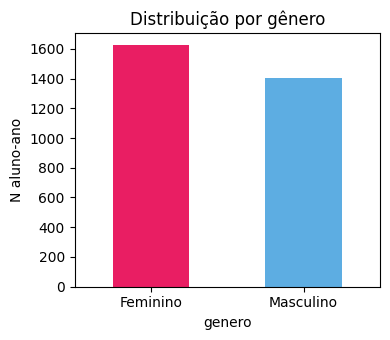


Indicadores médios por gênero:


,inde,ida,ieg,iaa,ips,ian
genero,,,,,,
Feminino,7.34,6.40,8.04,7.90,6.19,7.32
Masculino,7.19,6.35,7.84,7.93,6.40,7.02


In [5]:
print("Distribuição por gênero:")
display(df["genero"].value_counts())

fig, ax = plt.subplots(figsize=(4, 3.5))
df["genero"].value_counts().plot(kind="bar", color=["#E91E63", "#5DADE2"], ax=ax)
ax.set_ylabel("N aluno-ano"); ax.set_title("Distribuição por gênero")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

print("\nIndicadores médios por gênero:")
display(df.groupby("genero")[["inde", "ida", "ieg", "iaa", "ips", "ian"]].mean().round(2))

A base tem mais registros femininos (1.626) do que
masculinos (1.404). As alunas têm INDE, IDA, IEG e IAN médios levemente
superiores; os alunos têm IAA e IPS levemente superiores.

### Tipo de escola

In [6]:
# Normalização da instituição de ensino, que há inconsistencia entre os anos. Em 2022 os valores são nomes descritivos (`"Escola Pública"`, `"Rede Decisão"`), enquanto em 2023/2024 viraram categorias mais simples (`"Pública"`, `"Privada"`, `"Privada - Programa de Apadrinhamento"`.)
def simplifica_escola(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    if "Pública" in s:
        return "Pública"
    if "Concluiu" in s or "Formado" in s:
        return "Concluiu/Formado"
    if "Privada" in s or "Rede Decisão" in s:
        return "Privada"
    return "Outro"

df["Tipo_escola"] = df["instituicao_ensino"].apply(simplifica_escola)
display(df["Tipo_escola"].value_counts(dropna=False))

print("\nIndicadores médios por tipo de escola:")
display(df.groupby("Tipo_escola")[["inde", "ida", "ieg", "ian"]].mean().round(2))

Tipo_escola
Pública             2474
Privada              524
Concluiu/Formado      27
Outro                  4
NaN                    1
Name: count, dtype: int64


Indicadores médios por tipo de escola:


,inde,ida,ieg,ian
Tipo_escola,,,,
Concluiu/Formado,7.33,7.40,3.36,8.15
Outro,6.42,5.75,7.70,5.00
Privada,7.74,7.02,7.00,8.86
Pública,7.20,6.28,8.17,6.81


Alunos em escolas **privadas** têm INDE e IAN mais altos que os de
escola **pública** (7,74 vs. 7,20 de INDE; 8,86 vs. 6,81 de IAN), mas
**engajamento (IEG) menor** (7,00 vs. 8,17) — sugerindo que o suporte
acadêmico externo ajuda no desempenho, mas o engajamento com a Passos
Mágicos em si é mais forte entre os alunos de escola pública.

### Matriz de correlação

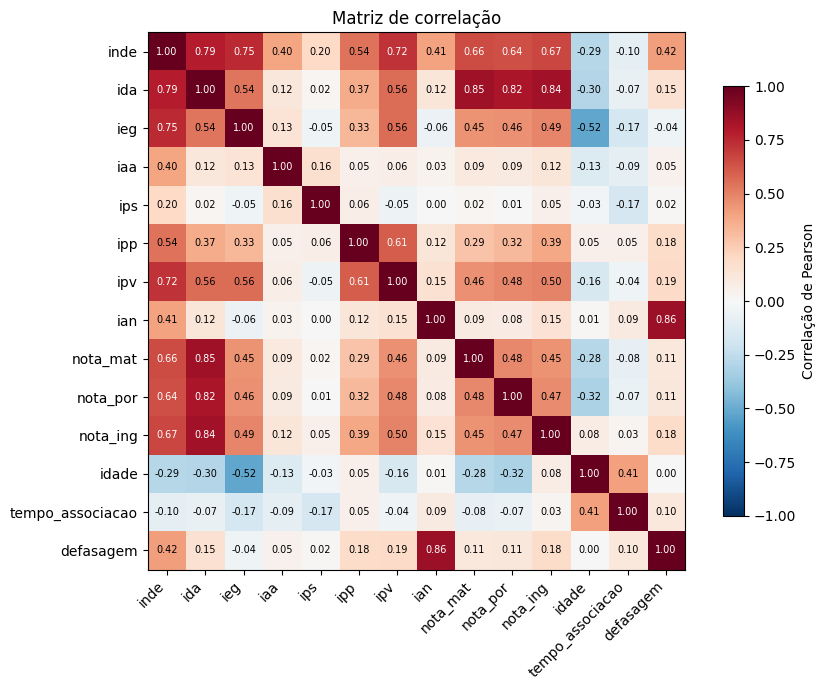

In [7]:
df["tempo_associacao"] = df["ano"] - df["ano_ingresso"]

cols_corr = ["inde", "ida", "ieg", "iaa", "ips", "ipp", "ipv", "ian",
             "nota_mat", "nota_por", "nota_ing", "idade", "tempo_associacao", "defasagem"]
corr_full = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_full.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_corr))); ax.set_xticklabels(cols_corr, rotation=45, ha="right")
ax.set_yticks(range(len(cols_corr))); ax.set_yticklabels(cols_corr)
for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        ax.text(j, i, f"{corr_full.values[i, j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr_full.values[i, j]) > 0.6 else "black", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlação de Pearson")
ax.set_title("Matriz de correlação")
plt.tight_layout(); plt.show()

Padrões novos chamam atenção:

- **Idade correlaciona negativamente com IEG (-0,52)** — uma relação mais
  forte do que qualquer correlação entre IEG e os demais indicadores
  acadêmicos. Alunos mais velhos se engajam visivelmente menos.
- **Idade também correlaciona negativamente com IDA (-0,30) e INDE (-0,29)**,
  reforçando que a transição para fases mais avançadas é um momento crítico.

### Notas por disciplina

,nota_mat,nota_por,nota_ing
ano,,,
2022,5.81,6.32,5.88
2023,6.41,6.82,6.20
2024,6.23,6.18,6.60


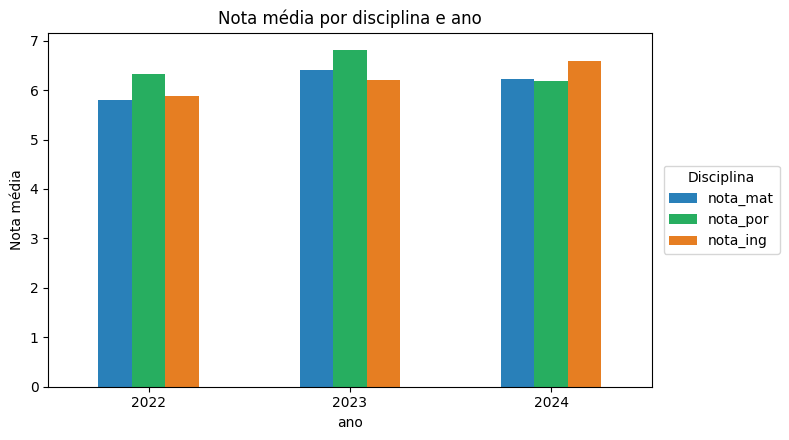

In [8]:
display(df.groupby("ano")[["nota_mat", "nota_por", "nota_ing"]].mean().round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
df.groupby("ano")[["nota_mat", "nota_por", "nota_ing"]].mean().plot(kind="bar", ax=ax,
    color=["#2980b9", "#27ae60", "#e67e22"])
ax.set_ylabel("Nota média"); ax.set_title("Nota média por disciplina e ano")
ax.legend(title="Disciplina", loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

Matemática é consistentemente a disciplina com a nota
mais baixa das três (exceto em 2024, quando Inglês assume essa posição) —
um indicativo de onde o reforço pedagógico pode ter mais impacto no IDA.

---

## Análise Exploratória - Para responder as perguntas de negócio

A partir daqui respondemos, uma a uma, as 11 perguntas de negócio do
enunciado do Datathon.

### Pergunta 1 — Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

defasagem_cat,Em fase/Avancado,Moderada,Severa
ano,,,
2022,30.1,47.7,22.2
2023,45.6,40.2,14.2
2024,53.8,38.1,8.0



IAN médio por ano:


ano
2022    6.42
2023    7.24
2024    7.68
Name: ian, dtype: float64

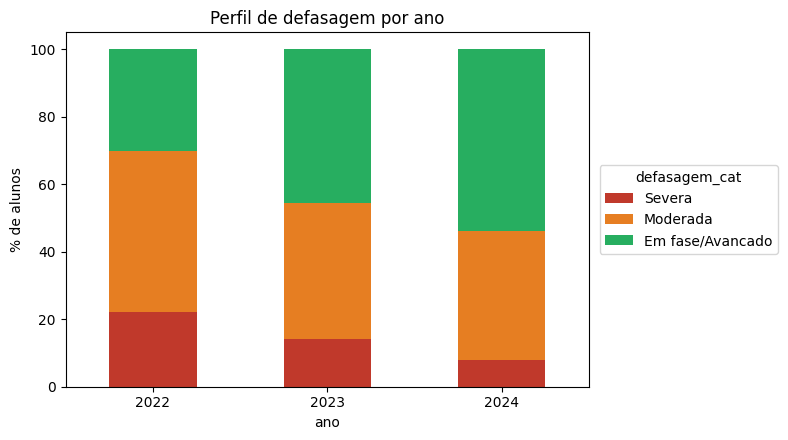

In [9]:
tab1 = df.groupby(["ano", "defasagem_cat"])["ra"].count().unstack()
tab1_pct = (tab1.T / tab1.sum(axis=1)).T * 100
display(tab1_pct.round(1))
print("\nIAN médio por ano:")
display(df.groupby("ano")["ian"].mean().round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
tab1_pct[["Severa", "Moderada", "Em fase/Avancado"]].plot(
    kind="bar", stacked=True, color=["#c0392b", "#e67e22", "#27ae60"], ax=ax)
ax.set_ylabel("% de alunos"); ax.set_title("Perfil de defasagem por ano")
ax.legend(title="defasagem_cat", loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Resposta:** A proporção de alunos severamente defasados cai de
**22,2% (2022) para 8,0% (2024)**, e o IAN médio sobe de 6,42 para 7,68 — o
sinal mais forte de que o programa está funcionando na adequação de
nível.

### Pergunta 2 — O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

ano
2022    6.09
2023    6.66
2024    6.35
Name: ida, dtype: float64

fase
0    7.30
1    6.68
2    6.19
3    5.39
4    5.97
5    6.14
6    6.92
7    5.93
8    8.00
9     NaN
Name: ida, dtype: float64

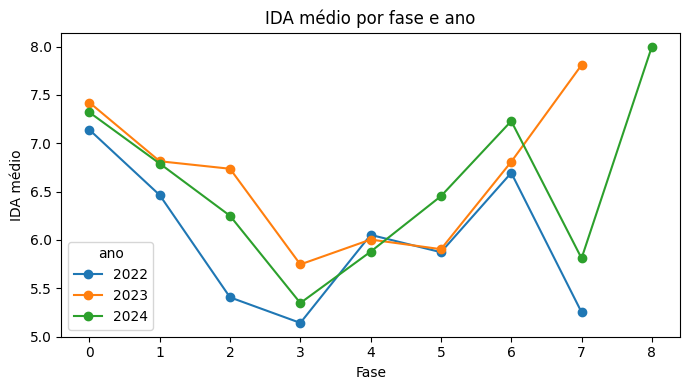

In [10]:
display(df.groupby("ano")["ida"].mean().round(2))
display(df.groupby("fase")["ida"].mean().round(2))

ax = df.groupby(["ano", "fase"])["ida"].mean().unstack(0).plot(marker="o", figsize=(7, 4))
ax.set_xlabel("Fase"); ax.set_ylabel("IDA médio"); ax.set_title("IDA médio por fase e ano")
plt.tight_layout(); plt.show()

**Resposta:** O IDA oscila. A **Fase 3 (7º/8º ano, IDA médio 5,39)** concentra o pior desempenho acadêmico de toda a jornada — a transição para o Fundamental II é um ponto crítico.

### Pergunta 3 — O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

In [11]:
display(df[["ieg", "ida", "ipv"]].corr().round(2))

,ieg,ida,ipv
ieg,1.00,0.54,0.56
ida,0.54,1.00,0.56
ipv,0.56,0.56,1.00


**Resposta:** Há uma correlação moderada (IEG-IDA = 0,54; IEG-IPV = 0,56) — mais engajamento, mais chance de bom desempenho e de atingir o Ponto de Virada, mas sem determinismo devido a correlação

### Pergunta 4 — As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

In [12]:
display(df[["iaa", "ida", "ieg"]].corr().round(2))

,iaa,ida,ieg
iaa,1.00,0.12,0.13
ida,0.12,1.00,0.54
ieg,0.13,0.54,1.00


**Resposta:** Correlação quase nula, a percepção do aluno sobre si mesmo está desconectada de seu desempenho e engajamento reais.

### Pergunta 5 — Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

In [13]:
piv = df.pivot_table(index="ra", columns="ano", values=["ips", "ida", "ieg"])
for (t, t1) in [(2022, 2023), (2023, 2024)]:
    sub = pd.DataFrame({
        "ips_t": piv[("ips", t)],
        "d_ida": piv[("ida", t1)] - piv[("ida", t)],
        "d_ieg": piv[("ieg", t1)] - piv[("ieg", t)],
    }).dropna()
    print(f"IPS({t}) x IDA({t}->{t1}): r={sub['ips_t'].corr(sub['d_ida']):.2f} | "
          f"IPS({t}) x IEG: r={sub['ips_t'].corr(sub['d_ieg']):.2f}  (n={len(sub)})")

IPS(2022) x IDA(2022->2023): r=0.06 | IPS(2022) x IEG: r=-0.01  (n=574)
IPS(2023) x IDA(2023->2024): r=0.05 | IPS(2023) x IEG: r=0.06  (n=679)


Comparamos o IPS de um ano com a **variação** de IDA/IEG no ano seguinte, aluno a aluno (não com o valor no mesmo ano, que não testaria antecipação).

**Resposta:** Correlações próximas de zero em todos os casos — não há evidência linear de que o IPS antecipe quedas futuras de desempenho ou engajamento nesta base.

### Pergunta 6 — As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

In [14]:
display(df[["ipp", "ian", "defasagem"]].corr().round(2))
print("\nIPP médio por categoria de defasagem:")
display(df.groupby("defasagem_cat")["ipp"].mean().round(2))

,ipp,ian,defasagem
ipp,1.00,0.12,0.18
ian,0.12,1.00,0.86
defasagem,0.18,0.86,1.00



IPP médio por categoria de defasagem:


defasagem_cat
Em fase/Avancado    7.68
Moderada            7.55
Severa              7.11
Name: ipp, dtype: float64

**Resposta:** Correlação direta fraca (0,12), mas o IPP médio cai de forma consistente conforme a defasagem piora (7,68 → 7,55 → 7,11) — confirma parcialmente, na direção esperada.

### Pergunta 7 — Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

In [15]:
corr7 = df[["ipv", "iaa", "ieg", "ips", "ipp", "ida"]].corr()["ipv"].drop("ipv").sort_values(ascending=False)
display(corr7.round(3))

ipp    0.607
ieg    0.558
ida    0.557
iaa    0.063
ips   -0.049
Name: ipv, dtype: float64

**Resposta:** O **IPP** (r=0,61) é o mais associado ao Ponto de Virada, seguido de engajamento (0,56) e desempenho acadêmico (0,56). Autoavaliação e psicossocial têm relação praticamente nula.

### Pergunta 8 — Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?</cell>


In [16]:
from sklearn.linear_model import LinearRegression

feat_cols = ["iaa", "ieg", "ips", "ipp", "ida", "ipv", "ian"]
corr8 = df[["inde"] + feat_cols].corr()["inde"].drop("inde").sort_values(ascending=False)
display(corr8.round(3))

sub8 = df[["inde"] + feat_cols].dropna()
reg = LinearRegression().fit(sub8[feat_cols], sub8["inde"])
coef = pd.Series(reg.coef_, index=feat_cols).sort_values(ascending=False)
print(f"\nPesos recuperados por regressão linear (R² = {reg.score(sub8[feat_cols], sub8['inde']):.3f}):")
display(coef.round(3))

ida    0.785
ieg    0.745
ipv    0.721
ipp    0.540
ian    0.405
iaa    0.397
ips    0.200
Name: inde, dtype: float64


Pesos recuperados por regressão linear (R² = 1.000):


ieg    0.200
ida    0.200
ipv    0.199
ipp    0.100
ips    0.100
iaa    0.100
ian    0.100
dtype: float64

A correlação simples já aponta IDA (0,79), IEG (0,75) e IPV (0,72) como os indicadores mais associados ao INDE.

A própria Passos Mágicos o define como uma média ponderada linear de IAN, IDA, IEG, IAA, IPS, IPP e IPV, com peso duplo para IDA, IEG e IPV. Como a relação real é linear por construção, então precisamos usar a  a regressão para recuperar os pesos exatos.

**Resposta:**: A combinação que mais eleva o INDE é justamente **IDA + IEG + IPV**, pois pesam o dobro dos demais indicadores na composição da nota. Na prática, investir em desempenho acadêmico, engajamento e ponto de virada é a alavanca mais eficiente para elevar o INDE de um aluno.


### Pergunta 10 — Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

inde   ida   ieg   iaa   ips
ano  pedra                                 
2022 Ametista  7.53  7.01  8.62  8.73  7.07
     Quartzo   5.24  3.14  5.26  6.42  6.55
     Topázio   8.37  8.25  9.28  9.17  7.35
     Ágata     6.61  5.25  7.54  8.15  6.63
2023 Ametista  7.51  6.87  8.95  7.52  4.96
     Quartzo   5.55  4.59  7.12  2.25  4.13
     Topázio   8.44  8.13  9.43  8.96  6.20
     Ágata     6.57  5.59  8.10  5.38  4.69
2024 Ametista  7.53  6.57  8.46  8.71  6.94
     Quartzo   5.40  3.11  5.04  7.22  5.96
     Topázio   8.47  8.19  9.40  9.00  7.09
     Ágata     6.60  4.92  7.07  8.24  6.70

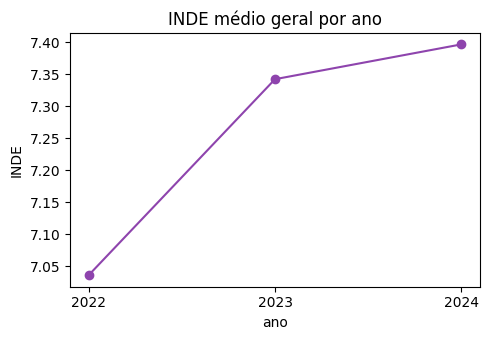


Jornada Pedra 2023->2024 (n=678): Subiu=164 | Manteve=339 | Desceu=175


In [17]:
display(df.groupby(["ano", "pedra"])[["inde", "ida", "ieg", "iaa", "ips"]].mean().round(2))

serie_inde = df.groupby("ano")["inde"].mean()
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(serie_inde.index.astype(str), serie_inde.values, marker="o", color="#8e44ad")
ax.set_title("INDE médio geral por ano"); ax.set_ylabel("INDE"); ax.set_xlabel("ano")
plt.tight_layout(); plt.show()

piv_pedra = df.pivot_table(index="ra", columns="ano", values="pedra", aggfunc="first")
ordem = {"Quartzo": 1, "Ágata": 2, "Ametista": 3, "Topázio": 4}
r23 = piv_pedra[2023].map(ordem); r24 = piv_pedra[2024].map(ordem)
delta = (r24 - r23).dropna()
print(f"\nJornada Pedra 2023->2024 (n={len(delta)}): Subiu={int((delta>0).sum())} | "
      f"Manteve={int((delta==0).sum())} | Desceu={int((delta<0).sum())}")

**Resposta:** O INDE por Pedra é estável . O sinal real de efetividade está na Pergunta 1 e na jornada de Pedra 2023→2024: **24% subiram, 50% mantiveram, 26% desceram**.

---

## Modelagem Preditiva de Risco de Defasagem

### Objetivo do bloco
Responder a pergunta 9: *"Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem."*

Usamos os indicadores do **ano *t*** para prever se o aluno ficará **defasado no ano seguinte (*t+1*)**.

In [18]:
FEATS_NUM = ["ida", "ieg", "iaa", "ips", "ipv", "inde", "ian", "fase", "idade", "defasagem"]
FEATS_CAT = ["genero"]
FEATS = FEATS_NUM + FEATS_CAT
# obs: "ipp" foi excluído por não existir na base de 2022.

def build_transition(df, ano_t, ano_t1):
    a = df[df.ano == ano_t][["ra"] + FEATS].copy()
    b = df[df.ano == ano_t1][["ra", "defasagem"]].rename(columns={"defasagem": "defasagem_next"})
    m = a.merge(b, on="ra", how="inner")
    m["target"] = (m["defasagem_next"] < 0).astype(int)
    return m

train_df = build_transition(df, 2022, 2023)
test_df = build_transition(df, 2023, 2024)
print("Treino (2022->2023):", train_df.shape, "| taxa de risco:", round(train_df.target.mean(), 3))
print("Teste  (2023->2024):", test_df.shape, "| taxa de risco:", round(test_df.target.mean(), 3))

Treino (2022->2023):

 (600, 14) | taxa de risco: 0.61
Teste  (2023->2024): (765, 14) | taxa de risco: 0.403


### Feature engineering

Imputação pela mediana + padronização para as variáveis numéricas;

In [19]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), FEATS_NUM),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))]), FEATS_CAT),
])

X_train, y_train = train_df[FEATS], train_df["target"]
X_test, y_test = test_df[FEATS], test_df["target"]

### Treino e avaliação — Regressão Logística vs. Random Forest vs. XGBoost

Três modelos: a Regressão Logística é o *baseline* interpretável; o Random Forest e o XGBoost capturam relações não lineares e interações entre variáveis, com o XGBoost construindo as árvores de forma
sequencial. 

Os três tratam o desbalanceamento entre alunos em risco e fora de risco: Logística e Random Forest via
`class_weight="balanced"`, XGBoost via `scale_pos_weight`.

In [20]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

modelos = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "random_forest": RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
    "xgboost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=scale_pos_weight, eval_metric="logloss",
                              random_state=RANDOM_STATE),
}

resultados = []
pipelines = {}
for nome, clf in modelos.items():
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    resultados.append({
        "modelo": nome, "auc": roc_auc_score(y_test, proba), "f1": f1_score(y_test, pred),
        "precisao": precision_score(y_test, pred), "recall": recall_score(y_test, pred),
        "acuracia": accuracy_score(y_test, pred),
    })
    pipelines[nome] = pipe
    print(f"\n--- {nome} ---")
    print(classification_report(y_test, pred, digits=3))

res_df = pd.DataFrame(resultados).set_index("modelo").round(3)
print("\nComparação de modelos (holdout temporal 2023->2024):")
display(res_df)
melhor = res_df["auc"].idxmax()
print(f"Melhor modelo por AUC: {melhor}")


--- logistic_regression ---
              precision    recall  f1-score   support

           0      0.738     0.875     0.801       457
           1      0.744     0.539     0.625       308

    accuracy                          0.740       765
   macro avg      0.741     0.707     0.713       765
weighted avg      0.741     0.740     0.730       765




--- random_forest ---
              precision    recall  f1-score   support

           0      0.790     0.858     0.823       457
           1      0.758     0.662     0.707       308

    accuracy                          0.779       765
   macro avg      0.774     0.760     0.765       765
weighted avg      0.777     0.779     0.776       765


--- xgboost ---
              precision    recall  f1-score   support

           0      0.800     0.867     0.832       457
           1      0.774     0.679     0.723       308

    accuracy                          0.791       765
   macro avg      0.787     0.773     0.778       765
weighted avg      0.790     0.791     0.788       765


Comparação de modelos (holdout temporal 2023->2024):


,auc,f1,precisao,recall,acuracia
modelo,,,,,
logistic_regression,0.808,0.625,0.744,0.539,0.740
random_forest,0.864,0.707,0.758,0.662,0.779
xgboost,0.870,0.723,0.774,0.679,0.791


Melhor modelo por AUC: xgboost


**Reposta:** O **XGBoost** vence (AUC ≈ 0,87, F1 ≈ 0,72), o ganho do boosting sobre o Random Forest é pequeno, mas consistente em todas as métricas.

---

## Exportando o modelo e o metadata.json

### Objetivo do bloco
Retreinar o melhor modelo com todos os dados disponíveis (2022-2024) e
salvar os artefatos que o app Streamlit.

In [ ]:
full_df = pd.concat([train_df, test_df], ignore_index=True)
X_full, y_full = full_df[FEATS], full_df["target"]

final_pipe = Pipeline([("prep", preprocess), ("clf", modelos[melhor])])
final_pipe.fit(X_full, y_full)

joblib.dump(final_pipe, "modelo_risco_defasagem.pkl")

metadata = {
    "modelo": {
        "nome": melhor,
        "features": FEATS,
        "target": "risco_defasagem_proximo_ciclo",
        "validacao": "temporal (treino 2022->2023, teste 2023->2024)",
        "test_auc": round(float(res_df.loc[melhor, "auc"]), 3),
        "test_f1": round(float(res_df.loc[melhor, "f1"]), 3),
        "test_precisao": round(float(res_df.loc[melhor, "precisao"]), 3),
        "test_recall": round(float(res_df.loc[melhor, "recall"]), 3),
        "test_acuracia": round(float(res_df.loc[melhor, "acuracia"]), 3),
        "descricao": "Probabilidade do aluno ficar defasado (Fase efetiva < Fase ideal) no próximo ciclo.",
    },
    "comparacao_modelos": res_df.to_dict(orient="index"),
    "dicionario_colunas": {
        "ida": "Desempenho Acadêmico (média Mat/Por/Ing)",
        "ieg": "Engajamento",
        "iaa": "Autoavaliação",
        "ips": "Psicossocial",
        "ipv": "Ponto de Virada",
        "inde": "Índice geral (ponderação dos demais)",
        "ian": "Adequação de Nível",
        "fase": "Fase atual (0=Alfa a 8=Universitário)",
        "idade": "Idade do aluno",
        "defasagem": "Fase efetiva - Fase ideal (atual)",
        "genero": "Feminino / Masculino",
    },
}
with open("metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Arquivos salvos: modelo_risco_defasagem.pkl, metadata.json")

Arquivos salvos: modelo_risco_defasagem.pkl, metadata.json
Coloque os dois arquivos na pasta 'models/' do repositório.
